Проект для попытки реализовать расчёт метрик

На своих данных (двумерных для простоты)

В этом проекте, основанного на MetricsKANTest, должно быть реаплизовано автоматическое обучение сети ( 50 раз) с сохранением получившихся метрик в файл csv 

Метрики должны быть расчитаны на основе 10% данных которые никак не участвовали в обучении 

In [68]:
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import *

In [69]:
input_path='file_for_input/all_hour/SBER_tradestats_test_hour.csv'
save_metrics_path = 'file_for_output/hour_metrics/KAN/SBER_metrics.csv'

In [70]:
from kan import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cpu


In [71]:

data = pd.read_csv(input_path)

# ['vol','val','trades','trades_b','trades_s', 'val_b','val_s','vol_b','vol_s','pr_open_hour','pr_high_hour','pr_low_hour','pr_close_hour'] <- полный список параметров



# # Создаём новую колонку, где целевая переменная смещена на -1 шаг
# data['next_pr_close_hour'] = data['pr_close_hour'].shift(-1)
# 
# # Удаляем последние строки, где нет следующего значения
# data = data.dropna()
# 
# # Формируем входные данные X и целевые метки Y
# X = data[['pr_close_hour']]  # Цена закрытия текущего часа
# Y = data['next_pr_close_hour']  # Цена закрытия следующего часа








date_df= data['tradedate'] + '-' + data['tradetime_hour'].astype(str)
X = data[['pr_open_hour']] # Не добавлются сюда другие лейблы
Y= data ['pr_close_hour']
# Разделение данных на обучающую и тестовую выборки те самые 10%
X, X10, Y, Y10 = train_test_split(X, Y, test_size=0.1, shuffle=False)
# X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [72]:
import time
# neurons_number = [1,5,10,15,20,30,50,100] - 75,40,150,200 , 2,3,4,5
# grid = [3, 6,10,20,] - 100,50,30,
# steps [20, 30, 50] - 100

#Остановились на переборе нейронов для сетки 10

# Параметры сети
secid = 'SBER'
neurons_number = 5
grid = 3
num_param= len(X.columns)
steps = 50
name = secid+ '_kan_' + 'n'+str(neurons_number) + 'g'+str(grid)+'s'+ str(steps) +'np' + str(num_param) 


num_rep = 1

save_metrics_path = 'file_for_output/hour_metrics/KAN/'+name+'.csv'
name

'SBER_kan_n5g3s50np1'

In [73]:
# Функция для вычисления метрик
def calculate_metrics(Y10, kan_predictions,name):
    
    rmse_kan = root_mean_squared_error(Y10, kan_predictions)
    mae_kan = mean_absolute_error(Y10, kan_predictions)
    mape_kan = mean_absolute_percentage_error(Y10, kan_predictions)
    r2_kan = r2_score(Y10, kan_predictions)
    msle_kan = mean_squared_log_error(Y10, kan_predictions)
    
    return rmse_kan, mae_kan, mape_kan, r2_kan, msle_kan, name

# Функция для сохранения метрик в CSV файл
def save_metrics_to_csv(metrics, filename=save_metrics_path):
    # Проверяем, существует ли файл
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        # Если файл не найден, создаём новый DataFrame с заданными колонками
        df = pd.DataFrame(columns=['RMSE', 'MAE', 'MAPE', 'R2', 'MSLE', 'Name'])
        # Сохраняем его, чтобы создать файл
        df.to_csv(filename, index=False)

    # Добавляем новые метрики в DataFrame
    new_row = pd.DataFrame([metrics], columns=['RMSE', 'MAE', 'MAPE', 'R2', 'MSLE', 'Name'])
    df = pd.concat([df, new_row], ignore_index=True)

    # Сохраняем DataFrame в CSV файл
    df.to_csv(filename, index=False)


In [74]:
save_metrics_path

'file_for_output/hour_metrics/KAN/SBER_kan_n5g3s50np1.csv'

In [75]:
# Функция для вычисления метрик
def calculate_metrics(Y10, kan_predictions,name):
    
    rmse_kan = root_mean_squared_error(Y10, kan_predictions)
    mae_kan = mean_absolute_error(Y10, kan_predictions)
    mape_kan = mean_absolute_percentage_error(Y10, kan_predictions)
    r2_kan = r2_score(Y10, kan_predictions)
    
    return rmse_kan, mae_kan, mape_kan, r2_kan, name

# Функция для сохранения метрик в CSV файл
def save_metrics_to_csv(metrics, filename=save_metrics_path):
    # Проверяем, существует ли файл
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        # Если файл не найден, создаём новый DataFrame с заданными колонками
        df = pd.DataFrame(columns=['RMSE', 'MAE', 'MAPE', 'R2', 'Name'])
        # Сохраняем его, чтобы создать файл
        df.to_csv(filename, index=False)

    # Добавляем новые метрики в DataFrame
    new_row = pd.DataFrame([metrics], columns=['RMSE', 'MAE', 'MAPE', 'R2', 'Name'])
    df = pd.concat([df, new_row], ignore_index=True)

    # Сохраняем DataFrame в CSV файл
    df.to_csv(filename, index=False)

In [76]:
fitdate= date_df[:len(Y)] # Даты для 90% основных данных, которые пойдут на обучение
date10 = date_df[len(Y):] # Даты для выделенных 10% данных

In [77]:
# Убедитесь, что device определен (проверить код в этой ячейке)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=42, shuffle=False)
train_date= fitdate[:len(y_train)] # Даты соответствующие тренировочной выборке
test_date= fitdate[len(y_train):] # Даты соответствующие тестовой выборке ( 40% данных отправленных на обучение)


# Преобразование в тензоры PyTorch
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Создание правильного датасета для KAN
dataset = {
    'train_input': X_train_tensor,
    'train_label': y_train_tensor,
    'test_input': X_test_tensor,
    'test_label': y_test_tensor
}

In [78]:
print("Размер обучающей выборки (X_train):", X_train.shape)
print("Размер тестовой выборки (X_test):", X_test.shape)
print("Размер меток обучающей выборки (y_train):", y_train.shape)
print("Размер меток тестовой выборки (y_test):", y_test.shape)

Размер обучающей выборки (X_train): (6521, 1)
Размер тестовой выборки (X_test): (1151, 1)
Размер меток обучающей выборки (y_train): (6521,)
Размер меток тестовой выборки (y_test): (1151,)


In [79]:
dataset['train_input'].shape, dataset['train_label'].shape 

(torch.Size([6521, 1]), torch.Size([6521, 1]))

Закончили обрабатывать данные и приступаем к обучению

In [80]:
import random
for i in range(steps):  # Пример цикла
    # Создание модели KAN с измененными параметрами
    model = KAN(width=[1, neurons_number, 1], grid=grid, k=3, seed=0) # убрал seed=0

    # Обучение модели
    #results = model2.train(dataset, opt="LBFGS", steps=20, lamb=0.01, lamb_entropy=10)
    results = model.fit(dataset, opt="LBFGS", steps=i)
    # # Вывод результатов
    # train_loss = results['train_loss'][-1]  # последнее значение обучающей ошибки
    # test_loss = results['test_loss'][-1]  # последнее значение ошибки на тесте
    # print(f'Train loss: {train_loss}, Test loss: {test_loss}')
    print ("epoch" + str(i+1))
    # Для KAN
    X_test_tensor = torch.tensor(X10.values, dtype=torch.float32)  # Преобразование в тензор, если еще не сделано
    kan_predictions = model(X_test_tensor).detach().numpy()  # Получение предсказаний и преобразование их в NumPy массив
    
    
    metrics = calculate_metrics(Y10, kan_predictions, name)
    save_metrics_to_csv(metrics)

checkpoint directory created: ./model
saving model version 0.0


description: 0it [00:00, ?it/s]
C:\Users\mrmag\AppData\Local\Temp\ipykernel_12132\2017607331.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


saving model version 0.1
epoch1
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.79e+00 | test_loss: 8.53e-01 | reg: 1.03e+01 | : 100%|█| 1/1 [00:00<00:00,  3.31it/s


saving model version 0.1
epoch2
checkpoint directory created: ./model
saving model version 0.0


...

saving model version 0.1
epoch48
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.79e+00 | test_loss: 8.53e-01 | reg: 1.03e+01 | : 100%|█| 48/48 [00:05<00:00,  9.17it


saving model version 0.1
epoch49
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.79e+00 | test_loss: 8.53e-01 | reg: 1.03e+01 | : 100%|█| 49/49 [00:06<00:00,  7.67it

saving model version 0.1
epoch50


Строим график обучения ( пока без тестовой проверки)

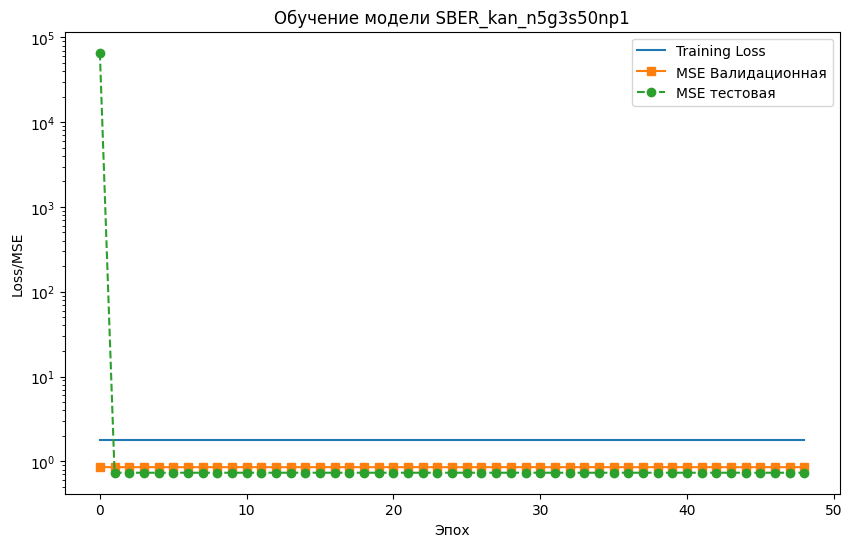

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка метрик из CSV
metrics_df = pd.read_csv('file_for_output/hour_metrics/KAN/'+name+'.csv')

# Вычисление MSE из RMSE
metrics_df['MSE'] = metrics_df['RMSE'] ** 2

# Построение графика
plt.figure(figsize=(10, 6))

# Добавление данных из истории обучения
plt.plot(results['train_loss'], label='Training Loss')
plt.plot(results['test_loss'], label='MSE Валидационная', marker='s')
# 
# # Добавление данных MSE, рассчитанных из RMSE
plt.plot(metrics_df['MSE'][:-1], label='MSE тестовая', linestyle='--', marker='o')
# 
#  # Настройка видимого диапазона оси y
# plt.ylim(metrics_df['MSE'][1:].min() * 0.9, metrics_df['MSE'][1:].max() * 1.1) # Если хочеться смотерть без 1 значения, то стоит закоментить эту строку

# Настройка графика
plt.yscale('log')
plt.title('Обучение модели '+ name)
plt.ylabel('Loss/MSE')
plt.xlabel('Эпох')
plt.legend()
plt.savefig('file_for_output/hour_metrics/KAN/graphics/' + name + 'graph_learn.png', bbox_inches='tight')
plt.show()

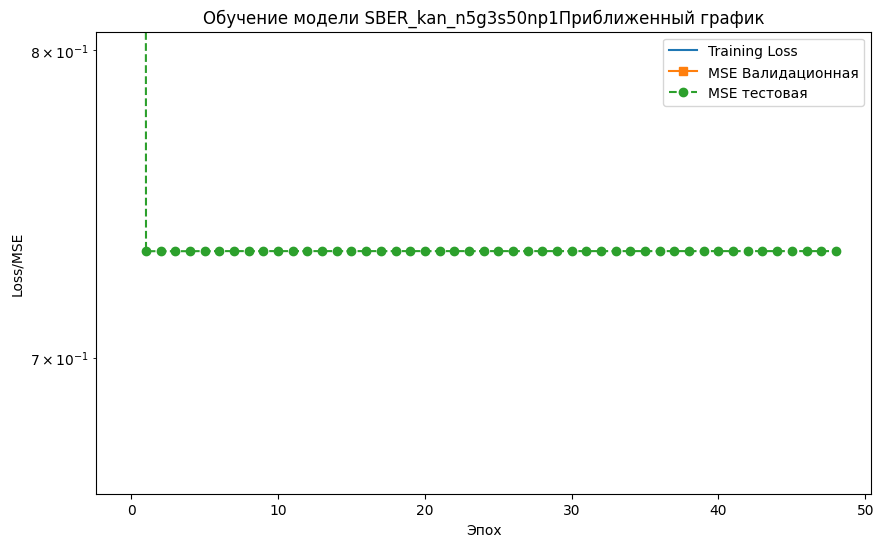

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка метрик из CSV
metrics_df = pd.read_csv('file_for_output/hour_metrics/KAN/'+name+'.csv')

# Вычисление MSE из RMSE
metrics_df['MSE'] = metrics_df['RMSE'] ** 2

# Построение графика
plt.figure(figsize=(10, 6))

# Добавление данных из истории обучения
plt.plot(results['train_loss'], label='Training Loss')
plt.plot(results['test_loss'], label='MSE Валидационная', marker='s')
# 
# # Добавление данных MSE, рассчитанных из RMSE
plt.plot(metrics_df['MSE'][:-1], label='MSE тестовая', linestyle='--', marker='o')
# 
#  # Настройка видимого диапазона оси y
plt.ylim(metrics_df['MSE'][1:].min() * 0.9, metrics_df['MSE'][1:].max() * 1.1) # Если хочеться смотерть без 1 значения, то стоит закоментить эту строку

# Настройка графика
plt.yscale('log')
plt.title('Обучение модели '+ name + 'Приближенный график')
plt.ylabel('Loss/MSE')
plt.xlabel('Эпох')
plt.legend()
plt.savefig('file_for_output/hour_metrics/KAN/graphics/' + name + 'graph_learn_scaled.png', bbox_inches='tight')
plt.show()


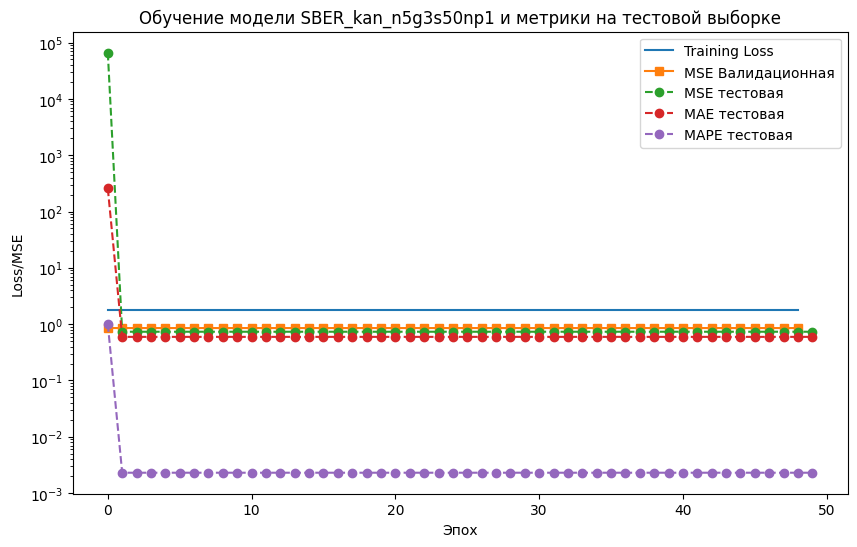

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка метрик из CSV
metrics_df = pd.read_csv('file_for_output/hour_metrics/KAN/'+name+'.csv')

# Вычисление MSE из RMSE
metrics_df['MSE'] = metrics_df['RMSE'] ** 2

# Построение графика
plt.figure(figsize=(10, 6))

# Добавление данных из истории обучения
plt.plot(results['train_loss'], label='Training Loss')
plt.plot(results['test_loss'], label='MSE Валидационная', marker='s')

# Добавление данных других метрик
plt.plot(metrics_df['MSE'], label='MSE тестовая', linestyle='--', marker='o')
plt.plot(metrics_df['MAE'], label='MAE тестовая', linestyle='--', marker='o')
plt.plot(metrics_df['MAPE'], label='MAPE тестовая', linestyle='--', marker='o')
# plt.plot(metrics_df['r2_lstm'], label='R2 тестовая', linestyle='--', marker='o')
# plt.plot(metrics_df['msle_lstm'], label='MSLE тестовая', linestyle='--', marker='o')

# Настройка графика
plt.yscale('log')
plt.title('Обучение модели '+ name+ ' и метрики на тестовой выборке')
plt.ylabel('Loss/MSE')
plt.xlabel('Эпох')
plt.legend()
plt.savefig('file_for_output/hour_metrics/LSTM/graphics/' + name + 'graph_learn_fullMetrics.png', bbox_inches='tight')
plt.show()

In [84]:
results

{'train_loss': [array(1.7855314, dtype=float32),
  array(1.7855314, dtype=float32),
  array(1.7855314, dtype=float32),
  array(1.7855315, dtype=float32),
  array(1.7855313, dtype=float32),
  array(1.7855313, dtype=float32),
  array(1.7855313, dtype=float32),
  array(1.7855312, dtype=float32),
  array(1.785531, dtype=float32),
  array(1.785531, dtype=float32),
  array(1.7855313, dtype=float32),
  array(1.7855312, dtype=float32),
  array(1.7855313, dtype=float32),
  array(1.7855312, dtype=float32),
  array(1.7855312, dtype=float32),
  array(1.7855313, dtype=float32),
  array(1.7855312, dtype=float32),
  array(1.7855312, dtype=float32),
  array(1.7855312, dtype=float32),
  array(1.7855312, dtype=float32),
  array(1.7855313, dtype=float32),
  array(1.7855313, dtype=float32),
  array(1.7855313, dtype=float32),
  array(1.7855313, dtype=float32),
  array(1.785531, dtype=float32),
  array(1.7855313, dtype=float32),
  array(1.7855312, dtype=float32),
  array(1.7855312, dtype=float32),
  array(1

Строим график предсказаний

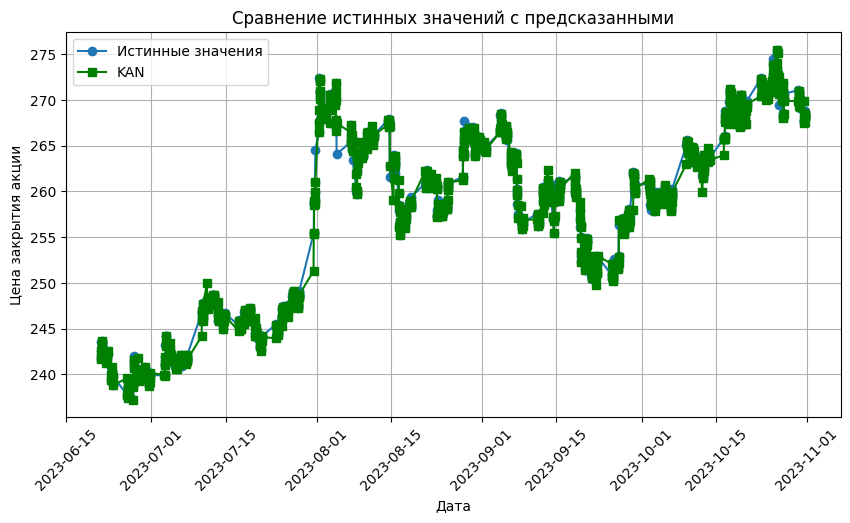

In [85]:
import matplotlib.pyplot as plt

date10 = pd.to_datetime(date10)
# Создание графика
plt.figure(figsize=(10, 5))
plt.plot(date10, Y10.reset_index(drop=True), label='Истинные значения', marker='o')
plt.plot(date10, kan_predictions, 'g', label='KAN', marker='s')
plt.title('Сравнение истинных значений с предсказанными')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия акции')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)  # Поворот меток дат для лучшей читаемости



# Сохранение графика в нужную директорию
plt.savefig('file_for_output/hour_metrics/KAN/graphics/'+name+'graph_full.png', bbox_inches='tight')
plt.show()

